# Build and Train a Spatiotemporal Graph Neural Network

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/...)

This notebook is a hands-on introduction to graph-based spatiotemporal modeling with PyTorch and PyTorch Geometric.

You will:
- build a small synthetic spatiotemporal graph dataset,
- implement a minimal spatiotemporal GNN (STGNN),
- train the model for next-step forecasting,
- evaluate predictions and visualize training behavior.

## Setup the environment
### Install the packages

In [ ]:
%pip -q install "torch>=2.5,<2.6" "torchvision>=0.20,<0.21" "torchaudio>=2.5,<2.6"
%pip -q install "torch-geometric>=2.7.0"

### Verify the environment

In [1]:
import torch
import torch_geometric

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch_geometric:", torch_geometric.__version__)

/Users/daniele.zambon/postdoc/spatiotemporal-learning-lab/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.5.1
cuda available: False
torch_geometric: 2.7.0


## A tiny dataset of correlated time series

### Build a graph
We start from a **toy ring graph**, where each node is connected to two neighbors.


In [2]:
import math
import torch
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- graph -----
num_nodes = 17

# Ring graph: each node connected to its two neighbors
edges = []
for i in range(num_nodes):
    j1 = (i + 1) % num_nodes
    j2 = (i - 1) % num_nodes
    edges.append((i, j1))
    edges.append((j1, i))
    edges.append((i, j2))
    edges.append((j2, i))

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)

print("Graph:")
print("edge_index shape", edge_index.shape)
print("edge_index:", edge_index)

Graph:
edge_index shape torch.Size([2, 68])
edge_index: tensor([[ 0,  1,  0, 16,  1,  2,  1,  0,  2,  3,  2,  1,  3,  4,  3,  2,  4,  5,
          4,  3,  5,  6,  5,  4,  6,  7,  6,  5,  7,  8,  7,  6,  8,  9,  8,  7,
          9, 10,  9,  8, 10, 11, 10,  9, 11, 12, 11, 10, 12, 13, 12, 11, 13, 14,
         13, 12, 14, 15, 14, 13, 15, 16, 15, 14, 16,  0, 16, 15],
        [ 1,  0, 16,  0,  2,  1,  0,  1,  3,  2,  1,  2,  4,  3,  2,  3,  5,  4,
          3,  4,  6,  5,  4,  5,  7,  6,  5,  6,  8,  7,  6,  7,  9,  8,  7,  8,
         10,  9,  8,  9, 11, 10,  9, 10, 12, 11, 10, 11, 13, 12, 11, 12, 14, 13,
         12, 13, 15, 14, 13, 14, 16, 15, 14, 15,  0, 16, 15, 16]])


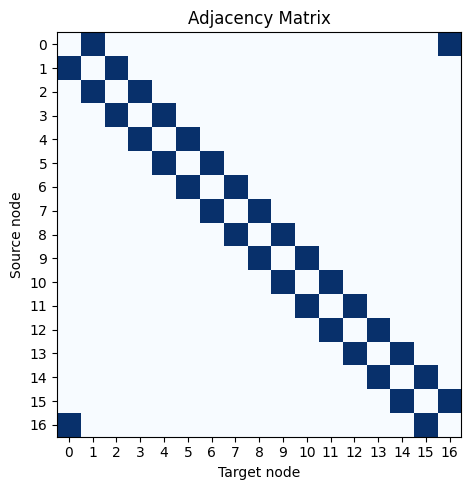

In [3]:
import matplotlib.pyplot as plt

# build and visualize adjacency matrix from edge_index
adj = torch.zeros((num_nodes, num_nodes), dtype=torch.float32)

adj[edge_index[0], edge_index[1]] = 1.0

plt.figure(figsize=(5, 5))
plt.imshow(adj.cpu(), cmap="Blues", interpolation="nearest")
plt.title("Adjacency Matrix")
plt.xlabel("Target node")
plt.ylabel("Source node")
# plt.colorbar(label="Edge")
plt.xticks(range(num_nodes))
plt.yticks(range(num_nodes))
plt.tight_layout()
plt.show()

### Generate correlated time series

We now simulate a **synthetic spatiotemporal signal** over the ring graph.

At each time step, every node value is updated as:
- a weighted average of its previous value and its two neighbors (**local diffusion**),
- plus a shared sinusoidal term (**global seasonality**, period 24),
- plus Gaussian noise (**stochastic perturbation**).

This produces node time series that are both:
- **spatially correlated** (through graph connectivity),
- **temporally correlated** (through autoregressive dynamics and seasonality).

The generated tensor `x_series` has shape `[T_total, num_nodes, num_features=1]`, and we then plot a few node trajectories to visually verify the correlation structure.

Generated spatiotemporal signal:
x_series shape: torch.Size([2000, 17, 1])


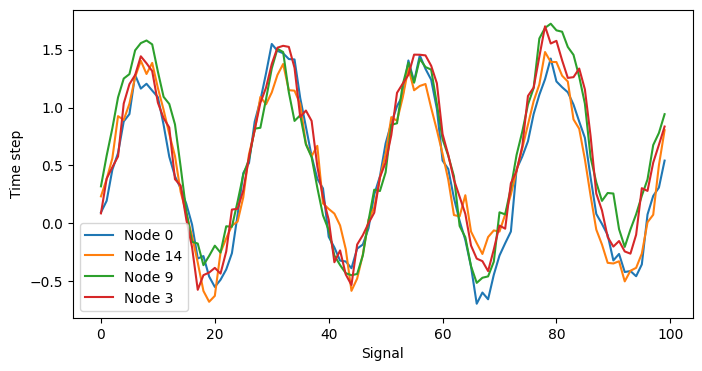

In [4]:

# ----- generate synthetic spatiotemporal signal -----
T_total = 2000
noise_level = 0.1
x_series = torch.zeros(T_total, num_nodes, 1)

# Initial state
x_series[0, :, 0] = torch.randn(num_nodes) * 0.2

for t in range(1, T_total):
    prev = x_series[t - 1, :, 0]

    # simple diffusion on the ring
    left = torch.roll(prev, shifts=1)
    right = torch.roll(prev, shifts=-1)
    spatial = 0.5 * prev + 0.25 * left + 0.25 * right

    # global seasonal component
    season = 0.23 * math.sin(2 * math.pi * t / 24.0)

    # noise
    noise = noise_level * torch.randn(num_nodes)

    x_series[t, :, 0] = spatial + season + noise


print("Generated spatiotemporal signal:")
print("x_series shape:", x_series.shape)

plt.figure(figsize=(8, 4))
# plt.plot(dataset.series[:100, sample_id % num_nodes])
for node in torch.randint(num_nodes, size=(4,)):
    plt.plot(x_series[100:200, node], label=f"Node {node}")
    # plt.plot([0, 100], [noise_level]*2, ":", label="Noise level", )
plt.xlabel("Signal")
plt.ylabel("Time step")
plt.legend()
plt.show()

In [5]:

# ----- supervised windows -----
window = 15
horizon = 1

class ToyDataset(Dataset):
    def __init__(self, series, window, horizon):
        self.series = series
        self.window = window
        self.horizon = horizon
        self.time_step = torch.arange(series.shape[0])

    def __len__(self):
        return len(self.series) - self.window - self.horizon

    def __getitem__(self, idx):
        t = idx + self.window
        x = self.series[t - self.window: t]          # [window, N, 1]
        y = self.series[t: t + self.horizon]         # [horizon, N, 1]
        # return x, y
        tx = self.time_step[t - self.window: t]
        ty = self.time_step[t: t + self.horizon]
        return x, y, tx, ty

dataset = ToyDataset(x_series, window, horizon)

n_train = int(0.8 * len(dataset))
n_val = len(dataset) - n_train
train_ds, val_ds = torch.utils.data.random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

print("Dataset:", len(dataset))
print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))
print("Example input shape:", dataset[0][0].shape)  # [window, N, 1]
print("Example target shape:", dataset[0][1].shape) # [horizon, N, 1]
print("Time steps input:", dataset[0][2])
print("Time steps target:", dataset[0][3])


Dataset: 1984
Train samples: 1587
Val samples: 397
Example input shape: torch.Size([15, 17, 1])
Example target shape: torch.Size([1, 17, 1])
Time steps input: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])
Time steps target: tensor([15])


In [6]:
one_batch = next(iter(train_loader))

print("Batch:", type(one_batch), "length:", len(one_batch), "(i.e., [x, y, tx, ty]")
print("Batch input shape:", one_batch[0].shape)  # [batch, window, N, 1]
print("Batch target shape:", one_batch[1].shape)  # [batch, horizon, N, 1]


Batch: <class 'list'> length: 4 (i.e., [x, y, tx, ty]
Batch input shape: torch.Size([32, 15, 17, 1])
Batch target shape: torch.Size([32, 1, 17, 1])


## Define a time-then-space STGNN


In [7]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv, GCNConv
from einops import rearrange

class SimpleSTGNN(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=16, horizon=1, out_channels=1):
        super().__init__()
        # Encoder
        self.encoder = nn.Linear(in_channels, hidden_channels)
        # Spatiotemporal message passing
        self.gru = nn.GRU(hidden_channels, hidden_channels, batch_first=True)
        self.gcn = GraphConv(hidden_channels, hidden_channels)
        # Decoder
        self.horizon = horizon
        self.decoder = nn.Linear(hidden_channels, horizon * out_channels)

    def forward(self, x, edge_index):
        """
        x: [B, T, N, F]
        edge_index: [2, E]
        returns: [B, N, 1]
        """
        B, T, N, F_in = x.shape

        # Encoder
        x_ = self.encoder(x)  # [B, T, N, hidden]

        # Temporal processing (each series independently)
        x_ = rearrange(x_, "b t n f -> (b n) t f")
        h, _ = self.gru(x_)     # [B N, T, H]
        last_h = h[:, -1, :]
        last_h = rearrange(last_h, "(b n) f -> b n f", b=B)

        # Spatial processing
        last_h = self.gcn(last_h, edge_index)   # [B, N, f]

        # Decoder
        y_hat = self.decoder(last_h)            # [B, N, h o]
        y_hat = rearrange(y_hat, "b n (h o) -> b h n o", h=self.horizon)

        return y_hat

dataset = ToyDataset(x_series, window, horizon=1)
model = SimpleSTGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print(model)

SimpleSTGNN(
  (encoder): Linear(in_features=1, out_features=16, bias=True)
  (gru): GRU(16, 16, batch_first=True)
  (gcn): GraphConv(16, 16)
  (decoder): Linear(in_features=16, out_features=1, bias=True)
)


## Train it

In [8]:
def run_epoch(loader, training=True, edge_index=None):
    model.train(training)
    total_loss = 0.0
    total_count = 0

    for x, y, tx, ty in loader: 
        x = x.to(device).float()
        y = y.to(device).float()

        if training:
            optimizer.zero_grad()

        y_hat = model(x, edge_index)
        assert y_hat.shape == y.shape, f"y_hat.shape {y_hat.shape} y.shape {y.shape}"
        loss = loss_fn(y_hat, y)

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_count += x.size(0)
        break

    return total_loss / total_count

history = {"train": [], "val": []}

for epoch in range(1, 501):
    train_loss = run_epoch(train_loader, training=True, edge_index=edge_index)
    val_loss = run_epoch(val_loader, training=False, edge_index=edge_index)

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}")


Epoch 01 | train 0.1843 | val 0.2412
Epoch 10 | train 0.1143 | val 0.1248
Epoch 20 | train 0.0798 | val 0.0861
Epoch 30 | train 0.0810 | val 0.0679
Epoch 40 | train 0.0501 | val 0.0545
Epoch 50 | train 0.0350 | val 0.0378
Epoch 60 | train 0.0295 | val 0.0294
Epoch 70 | train 0.0245 | val 0.0260
Epoch 80 | train 0.0215 | val 0.0239
Epoch 90 | train 0.0218 | val 0.0235
Epoch 100 | train 0.0186 | val 0.0229
Epoch 110 | train 0.0206 | val 0.0216
Epoch 120 | train 0.0199 | val 0.0216
Epoch 130 | train 0.0187 | val 0.0209
Epoch 140 | train 0.0186 | val 0.0208
Epoch 150 | train 0.0163 | val 0.0199
Epoch 160 | train 0.0183 | val 0.0204
Epoch 170 | train 0.0168 | val 0.0192
Epoch 180 | train 0.0160 | val 0.0188
Epoch 190 | train 0.0181 | val 0.0189
Epoch 200 | train 0.0162 | val 0.0189
Epoch 210 | train 0.0180 | val 0.0183
Epoch 220 | train 0.0188 | val 0.0177
Epoch 230 | train 0.0143 | val 0.0174
Epoch 240 | train 0.0159 | val 0.0173
Epoch 250 | train 0.0155 | val 0.0171
Epoch 260 | train 0.01

## Plot the learning curve

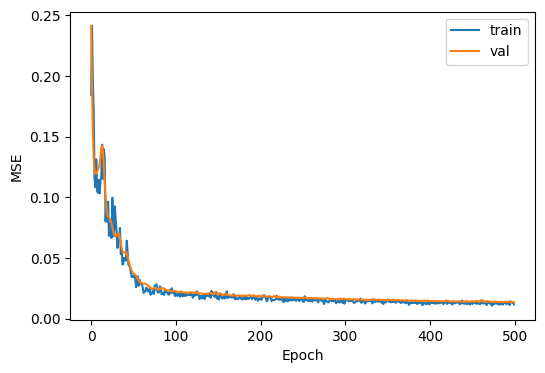

In [9]:

plt.figure(figsize=(6, 4))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

## Inspect one prediction

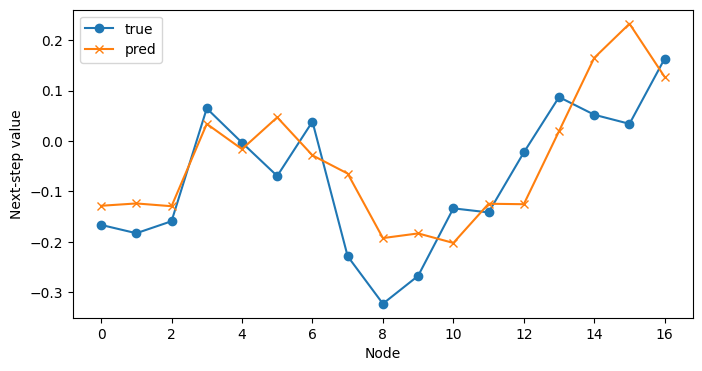

In [10]:
model.eval()

x_batch, y_batch, tx_batch, ty_batch = next(iter(val_loader))
x_batch = x_batch.to(device).float()
y_batch = y_batch.to(device).float()

with torch.no_grad():
    y_hat = model(x_batch, edge_index)

sample_id = int(torch.randint(len(val_loader), size=(1,)))

true_vals = y_batch[sample_id, 0].cpu()
pred_vals = y_hat[sample_id, 0].cpu()

plt.figure(figsize=(8, 4))
plt.plot(true_vals, marker="o", label="true")
plt.plot(pred_vals, marker="x", label="pred")
plt.xlabel("Node")
plt.ylabel("Next-step value")
plt.legend()
plt.show()
